# № 1
## (2 балла)
Реализуйте или найдите реализации двух сортировок: сортировка выбором и быстрая сортировка. Проведите вычислительные эксперименты и нарисуйте графики, показывающие зависимость времени выполнения двух алгоритмов от размера входных данных. Рассмотрите три варианта входных данных:
1. Список случайных чисел
2. Отсортированный список
3. Отсортированный в обратную сторону список

Для каждого из вариантов должен быть свой график зависимости.

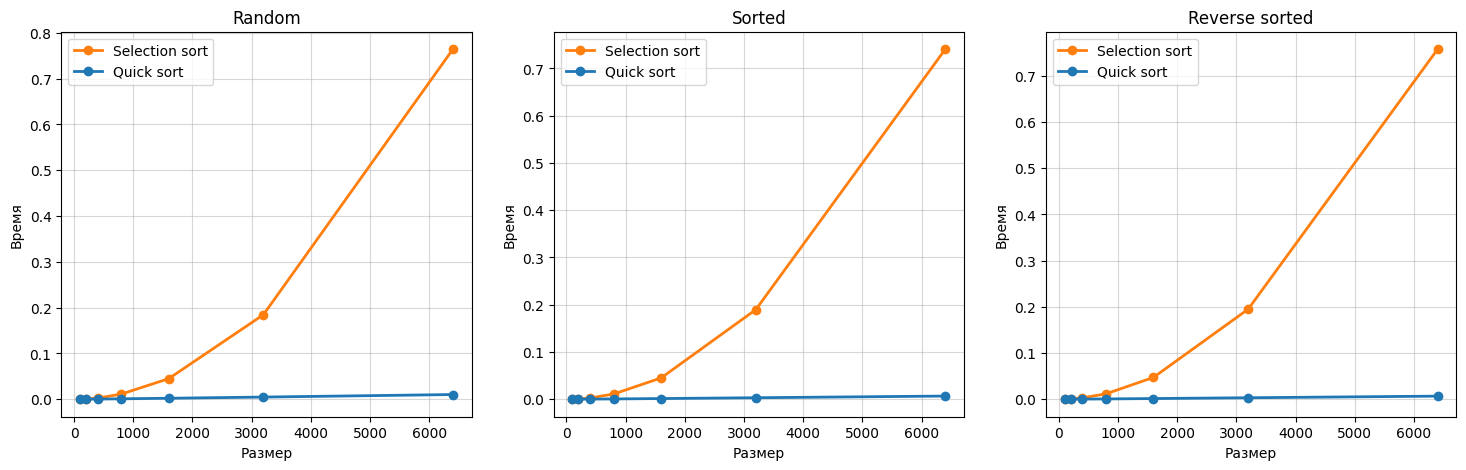

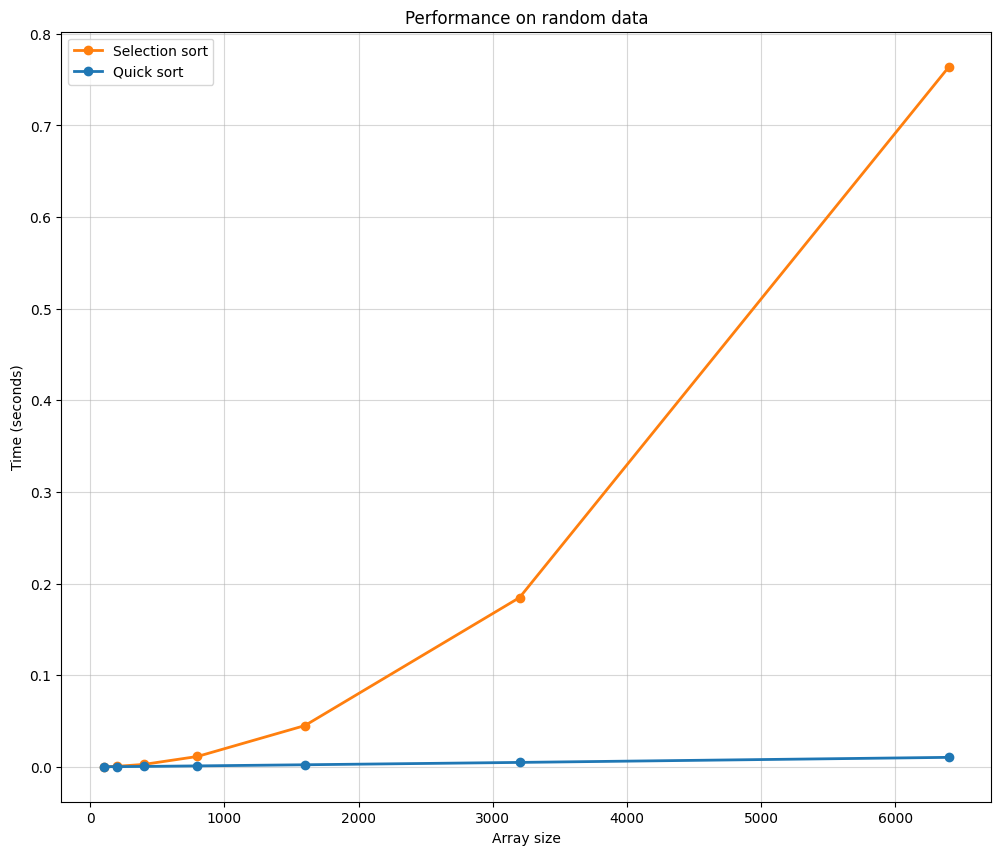

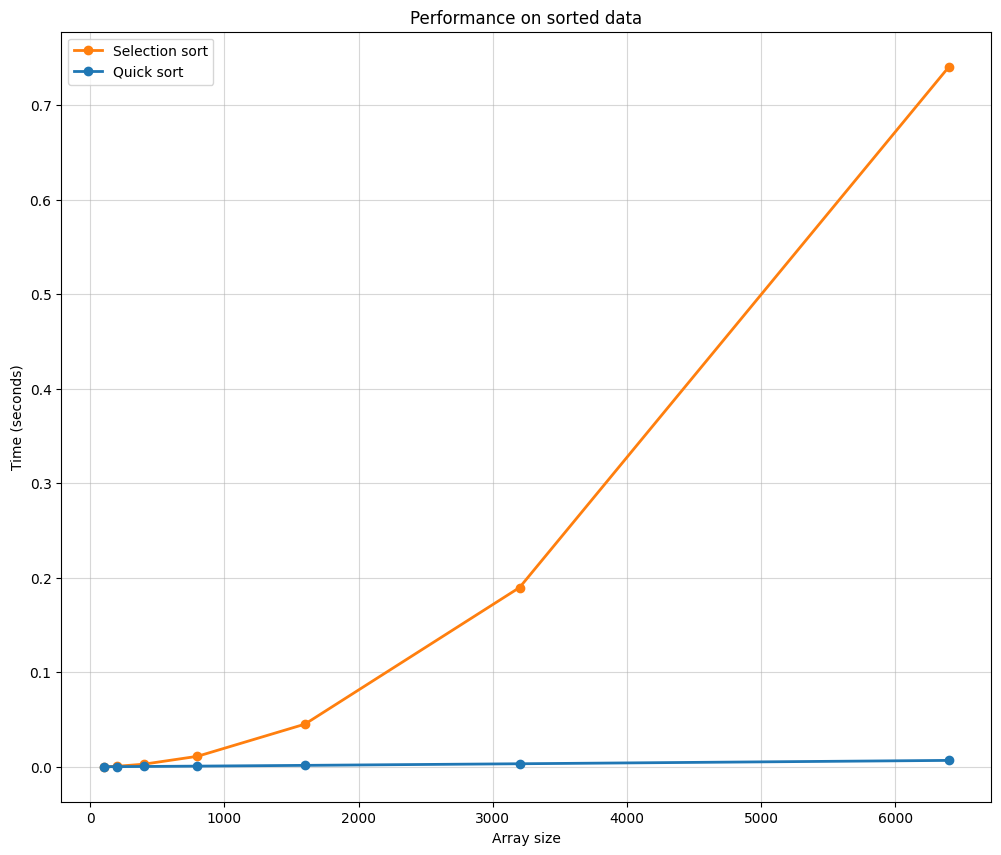

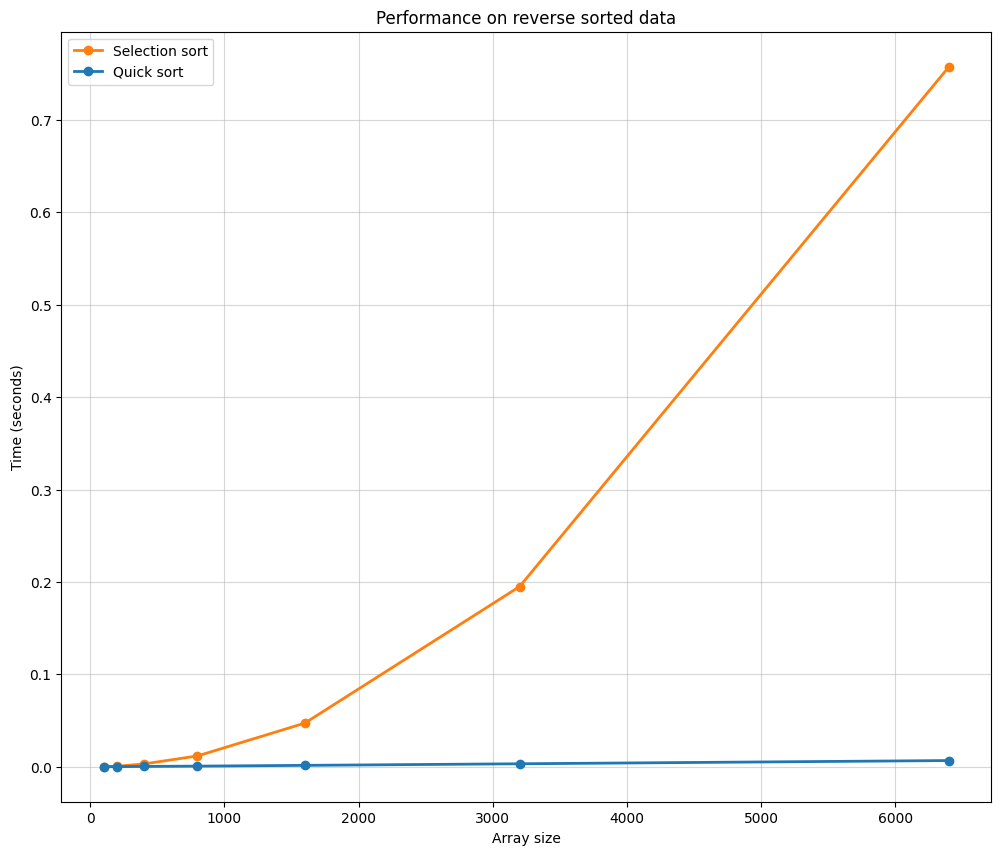

In [ ]:
import matplotlib.pyplot as plt
import random, time

def selection_sort(arr):
    arr = arr.copy()
    n = len(arr)
    for i in range(n):
        min_idx = i
        for j in range(i + 1, n):
            if arr[j] < arr[min_idx]:
                min_idx = j
        arr[i], arr[min_idx] = arr[min_idx], arr[i]
    return arr

def quick_sort(arr):
    if len(arr) <= 1:
        return arr[:]
    pivot = arr[len(arr) // 2]
    left = [x for x in arr if x < pivot]
    middle = [x for x in arr if x == pivot]
    right = [x for x in arr if x > pivot]
    return quick_sort(left) + middle + quick_sort(right)

def timing_func(func, data):
    start_time = time.perf_counter()
    func(data)
    end_time = time.perf_counter()
    return (end_time - start_time)

def gen_ran_data(size):
    return [random.randint(0, 10**6) for _ in range(size)]

def gen_sorted_data(size):
    return list(range(size))

def gen_reverse_sorted_data(size):
    return list(range(size, -1, -1))

data_sizes = [100, 200, 400, 800, 1600, 3200, 6400]
algos = {
    'Selection sort': selection_sort,
    'Quick sort': quick_sort
}
dtypes = {
    'Random': gen_ran_data,
    'Sorted': gen_sorted_data,
    'Reverse sorted': gen_reverse_sorted_data
}

results = {algo: {dtype: [] for dtype in dtypes} for algo in algos}
TRIALS = 5
for size in data_sizes:
    for dtype_name, data_gen in dtypes.items():
        test_data = data_gen(size)
        
        for algo_name, algo_func in algos.items():
            times = []
            for _ in range(TRIALS):
                data_copy = test_data.copy()
                times.append(timing_func(algo_func, data_copy))
            avg_time = sum(times) / len(times)
            results[algo_name][dtype_name].append(avg_time)
# имеем data_sizes, results

# Графики:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
dtypes = list(dtypes.keys())
ALPHA = 0.5
colors = {'Selection sort': '#ff7f0e', 'Quick sort': '#1f77b4'}

for i, dtype in enumerate(dtypes):
    ax = axes[i]
    for algo_name in results.keys():
        times = results[algo_name][dtype]
        ax.plot(data_sizes, times, marker='o', label=algo_name, color=colors[algo_name], linewidth=2)
        
    ax.set_title(f'{dtype}')
    ax.set_xlabel('Размер')
    ax.set_ylabel('Время')
    ax.grid(True, alpha=ALPHA)
    ax.legend()
plt.show()

for dtype in dtypes:
    plt.figure(figsize=(12, 10))
    for algo_name in algos.keys():
        times = results[algo_name][dtype]
        plt.plot(data_sizes, times, marker='o', color=colors[algo_name], label=algo_name, linewidth=2)
        
    plt.title(f'Performance on {dtype.lower()} data')
    plt.xlabel('Array size')
    plt.ylabel('Time (seconds)')
    plt.grid(True, alpha=ALPHA)
    plt.legend()
    plt.show()

# № 2
## (2 балла)
Ряд Трибоначчи начинается с тройки 0, 0, 1, а каждое следующее число равно сумме трёх предыдущих. Числа нумеруются с 0.

Напишите функцию tribonacci(n), которая принимает в себя номер числа и возвращает n-ое число Трибоначчи. Функция должна быть рекурсивной.

При решении данной задачи не используйте циклы.

Укажите базовый и рекурсивный случаи функции.

In [27]:
def tribonacci(n):
    if n == 0:
        return 0
    if n == 1:
        return 0
    if n == 2:
        return 1
    else:
        return tribonacci(n-1) + tribonacci(n-2) + tribonacci(n-3)

# [0, 0, 1, 1, 2, 4, 7, 13, 24, 44]

print(tribonacci(0))
print(tribonacci(1))
print(tribonacci(2))
print(tribonacci(3))
print(tribonacci(4))
print(tribonacci(5))
print(tribonacci(5))
print(tribonacci(6))
print(tribonacci(7))
print(tribonacci(8))
print(tribonacci(9))

0
0
1
1
2
4
4
7
13
24
44


# № 3
## (2 балла)
Для задачи вашего варианта напишите подходящую рекурсивную функцию.

При решении задачи **не используйте циклы.**

Укажите базовый и рекурсивный случаи вашей функции

**3 вариант**

Напишите рекурсивную функцию recursive_two(some_list), которая возвращает кортеж из двух значений – наибольший элемент списка some_list и второй наибольший его элемент.

In [33]:
def merge_pairs(pair1, pair2):
    max1, max1_2 = pair1
    max2, max2_2 = pair2
    
    if max1 is None:
        return (max2, max2_2)
    if max2 is None:
        return (max1, max1_2)
    # ===
    if max1 >= max2:
        overall_max = max1
        a = max2
        b = max1_2
    else:
        overall_max = max2
        a = max1
        b = max2_2
    # ===
    if not a is None and b is None:
        overall_max_2 = None
    elif a is None:
        overall_max_2 = b
    elif b is None:
        overall_max_2 = a
    else:
        if a >= b:
            overall_max_2 = a
        else:
            overall_max_2 = b
    return (overall_max, overall_max_2)

def recursive_two(some_list):           
    # Базовые случаи:
    if len(some_list) == 0:
        return (None, None)
    
    if len(some_list) == 1:
        return(some_list[0], None)
    
    if len(some_list) == 2:
        if some_list[0] > some_list[1]:
            return (some_list[0], some_list[1])
        else:
            return (some_list[1], some_list[0])
    
    # рекурсивный: basically quick_sort
    mid = len(some_list) // 2
    left = some_list[:mid]
    right = some_list[mid:]
    left_max1, left_max2 = recursive_two(left)
    right_max1, right_max2 = recursive_two(right)
    
    return merge_pairs((left_max1, left_max2), (right_max1, right_max2))

def random_list(n=10, low=-100, high=100, seed=None):
    if seed is not None:
        random.seed(seed)
    return [random.randint(low, high) for _ in range(n)]

def builtin_check(some_list):
    if not some_list:
        return (None, None)
    arr_copy = some_list.copy()
    max1 = max(arr_copy)
    idx = arr_copy.index(max1)
    arr_copy.pop(idx)
    if len(some_list) == 1:
        return (max1, arr_copy)
    max2 = max(arr_copy)
    return max1, max2

# тестим

arr = random_list()
print(f'Значения: {arr}')
print(f'Результат: {recursive_two(arr)}')
print(f'Проверим ч/з встр. ф-цию max: {builtin_check(arr)}')

Значения: [-7, -73, 21, -52, -98, 93, 9, 33, -66, -52]
Результат: (93, 33)
Проверим ч/з встр. ф-цию max: (93, 33)


# № 4
## (2 балла)
Числа Фибоначчи - это последовательность, которая вычисляется по рекуррентному соотношению 

`FN = FN - 1 + FN - 2`, 
где `F0 = 0`, а `F1 = 1`.

Числа Люка задаются примерно так же:

`LN = LN - 1 + LN - 2`, 
где `L0 = 2`, а `L1 = 1`. 

Пользуясь стандартным рекурсивным подходом, напишите две функции - `fibonacci(n)` и `lucas(n)`, которые будут вычислять `n`-е число Фибоначчи и Люка соответственно.

Измерьте время, которое требуется для вычисления `FN` и `LN` вплоть до `N = 40`. 

Если ваш компьютер достаточно быстрый, `N` стоит увеличить для повышения точности, а если слишком медленный - уменьшить, чтобы измерения заканчивались за приемлемое время.

Затем напишите функцию `fib_with_lucas(n)` и вспомогательную к ней, `lucas_with_fib(n)`, пользуясь такими свойствами этих последовательностей:
- `fib_with_lucas(n)` – если поделить `n` нацело пополам и взять `i = n // 2`, а `j = n - i`, то
`Fn = Fi + j = (Fi + Lj) (Fj + Li) // 2`;
- `lucas_with_fib(n)` – в свою очередь, `LN = FN - 1+FN + 1`.

Сравните быстродействие `fibonacci()` и `fib_with_lucas()`. Постройте график.

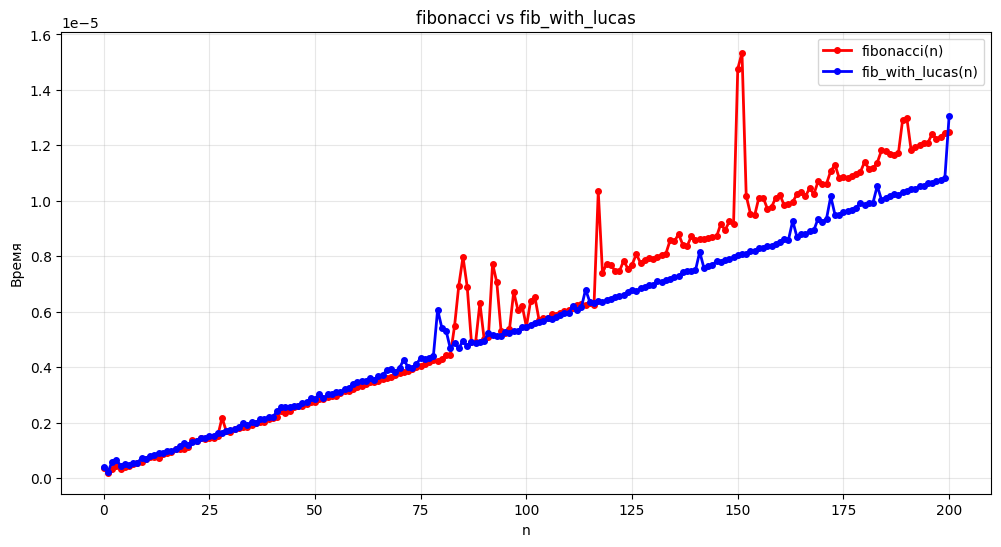

In [89]:
import functools

@functools.lru_cache(maxsize=None)
def fibonacci(n):
    if n == 0:
        return 0
    if n == 1:
        return 1
    else:
        return fibonacci(n-1) + fibonacci(n-2)

@functools.lru_cache(maxsize=None)
def lucas(n):
    if n == 0:
        return 2
    if n == 1:
        return 1
    else:
        return lucas(n-1) + lucas(n-2)

@functools.lru_cache(maxsize=None)
def fib_with_lucas(n):
    """F_n = (F_i + L_j) * (F_j + L_i) // 2"""
    if n == 0:
        return 0
    elif n == 1:
        return 1
    
    i = n // 2
    j = n - i
    
    F_i = fibonacci(i)
    F_j = fibonacci(j)
    L_i = lucas(i)
    L_j = lucas(j)
    
    return (F_i + L_j) * (F_j + L_i) // 2

@functools.lru_cache(maxsize=None)
def lucas_with_fib(n):
    """L_n = F_n-1 + F_n+1"""
    if n == 0:
        return 2
    if n == 1:
        return 1
    return fibonacci(n-1) + fibonacci(n+1)


N = 200
n_values = list(range(N+1))

times_fib = []
times_fib_with_lucas = []

for n in n_values:
    fibonacci.cache_clear()
    times = []
    for _ in range(TRIALS):
        time_taken = (timing_func(fibonacci, n))
        times.append(time_taken)
    avg_time = sum(times) / len(times)
    times_fib.append(avg_time)

for n in n_values:
    fibonacci.cache_clear()
    lucas.cache_clear()
    fib_with_lucas.cache_clear()
    times = []
    for _ in range(TRIALS):
        time_taken = timing_func(fib_with_lucas, n)
        times.append(time_taken)
    avg_time = sum(times) / len(times)
    times_fib_with_lucas.append(avg_time)
    
plt.figure(figsize=(12, 6))
plt.plot(n_values, times_fib, 'ro-', label='fibonacci(n)', linewidth=2, markersize=4)
plt.plot(n_values, times_fib_with_lucas, 'bo-', label='fib_with_lucas(n)', linewidth=2, markersize=4)

plt.xlabel('n')
plt.ylabel('Время')
plt.title('fibonacci vs fib_with_lucas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# № 5
## (3 балла)
Хорошим примером для иллюстрации рекурсивных алгоритмов являются задачи рисования фракталов. Далее представлена программа, которая при помощи модуля turtle ([turtle — Turtle graphics — Python 3.9.7 documentation](https://docs.python.org/3/library/turtle.html)) рисует фрактальное дерево.

```
import turtle

def tree(branchLen, t):
    if branchLen > 5:
        t.forward(branchLen)
        t.right(20)
        tree(branchLen - 15, t)
        t.left(40)
        tree(branchLen - 15, t)
        t.right(20)
        t.backward(branchLen)

def main():
    t = turtle.Turtle()
    myWin = turtle.Screen()
    t.left(90)
    t.up()
    t.backward(100)
    t.down()
    t.color("green")
    tree(75, t)
    myWin.exitonclick()

main()
```

Запустите программу и разберитесь в ее коде. Попробуйте поменять параметры при вызове функции tree и внутри нее.

Последовательно измените программу для рисования рекурсивного дерева по следующим пунктам:
1. Измените толщину ветвей, чтобы при уменьшении branchLen линии становились тоньше.
2. Измените цвет ветвей таким образом, чтобы самые короткие ветви окрашивались как листья.
3. Измените угол поворота черепахи, чтобы каждая ветвь поворачивалась произвольным образом в некотором диапазоне. Например, выбирайте угол между 15-ю и 45-ю градусами. Поэкспрериментируйте в поисках лучшего вида.
4. Измените рекурсивную часть branchLen, чтобы каждый раз вычиталось произвольное значение из некоторого диапазона вместо некой постоянной величины.

В отчете приведите несколько примеров получившихся деревьев. 

In [1]:
import turtle

BROWN_COLOR = "#4D2E10"
GREEN_COLOR = "#66D466"

# 0: Исходная
def tree(branchLen, t):
    if branchLen > 5:
        t.forward(branchLen)
        t.right(20)
        tree(branchLen - 15, t)
        t.left(40)
        tree(branchLen - 15, t)
        t.right(20)
        t.backward(branchLen)

def main5_0():
    t = turtle.Turtle()
    myWin = turtle.Screen()
    t.left(90)
    t.up()
    t.backward(100)
    t.down()
    t.color("green")
    tree(75, t)
    myWin.exitonclick()

# 1: Измените толщину ветвей
def tree_1(branchLen, t, width=10):  
    if branchLen > 5:  
        t.pensize(max(1, width))
        t.forward(branchLen)
        t.right(20)
        tree_1(branchLen - 15, t, width=width - 2)
        t.left(40)
        tree_1(branchLen - 15, t, width=width - 2)
        t.right(20)
        t.backward(branchLen)

def main5_1():
    t = turtle.Turtle()
    myWin = turtle.Screen()
    t.left(90)
    t.up()
    t.backward(100)
    t.down()
    t.color("green")
    tree_1(75, t)
    myWin.exitonclick()

def change_color(branchLen):
    return GREEN_COLOR if branchLen <= 15 else BROWN_COLOR

# 2: Измените цвет ветвей
def tree_2(branchLen, t, width=10):
    if branchLen > 5:
        # текущий сегмент
        t.color(change_color(branchLen))
        t.pensize(max(1, width))
        t.forward(branchLen)

        # правая ветвь
        child_len = branchLen - 15
        t.right(20)
        prev = t.pencolor()
        t.color(change_color(child_len))
        tree_2(child_len, t, width=width-2)
        t.color(prev)

        # левая ветвь
        child_len = branchLen - 15
        t.left(40)
        prev = t.pencolor()
        t.color(change_color(child_len))
        tree_2(child_len, t, width=width-2)
        t.color(prev)

        t.right(20)
        t.backward(branchLen)


def main5_2():
    t = turtle.Turtle()
    myWin = turtle.Screen()
    t.left(90)
    t.up()
    t.backward(100)
    t.down()
    tree_2(75, t)
    myWin.exitonclick()

# 3: Случайный угол поворота
def tree_3(branchLen, t, width=10):
    if branchLen > 5:
        t.color(change_color(branchLen))
        t.pensize(max(1, width))
        t.forward(branchLen)

        # правая ветвь со случайным углом
        right_angle = random.randint(15, 45)
        child_len = branchLen - 15
        t.right(right_angle)
        prev = t.pencolor()
        t.color(change_color(child_len))
        tree_3(child_len, t, width=width-2)
        t.color(prev)

        # левая ветвь со случайным углом
        left_angle = random.randint(15, 45)
        child_len = branchLen - 15
        t.left(right_angle + left_angle)
        prev = t.pencolor()
        t.color(change_color(child_len))
        tree_3(child_len, t, width=width-2)
        t.color(prev)

        t.right(left_angle)
        t.backward(branchLen)
   
def main5_3():
    t = turtle.Turtle()
    myWin = turtle.Screen()
    t.left(90)
    t.up()
    t.backward(100)
    t.down()
    tree_3(75, t)
    myWin.exitonclick()

# 4: Вычитание случайной длины + всё остальное
def tree_4(branchLen, t, width=10):
    if branchLen > 5:
        # текущий сегмент
        t.color(change_color(branchLen))
        t.pensize(max(1, width))
        t.forward(branchLen)

        # правая ветвь
        angle = random.randint(15, 45)
        t.right(angle)
        reduction = random.randint(10, 20)
        next_len = max(5, branchLen - reduction)
        prev = t.pencolor()
        t.color(change_color(next_len))
        tree_4(next_len, t, width=width - 2)
        t.color(prev)

        # левая ветвь
        t.left(angle * 2)
        reduction = random.randint(10, 20)
        next_len = max(5, branchLen - reduction)
        prev = t.pencolor()
        t.color(change_color(next_len))
        tree_4(next_len, t, width=width - 2)
        t.color(prev)

        t.right(angle)
        t.backward(branchLen)

def main5_4():
    t = turtle.Turtle()
    myWin = turtle.Screen()
    t.left(90)
    t.up()
    t.backward(100)
    t.down()
    tree_4(75, t)
    myWin.exitonclick()

print("Какую версию хотите запустить:")
print(" 0 - Исходная")
print(" 1 - Толщина ветвей")
print(" 2 - Цвет + толщина ветвей")
print(" 3 - Цвет + толщина + угол")
print(" 4 - Цвет + толщина + угол + длина")

choice = int(input("Ваш выбор -> "))
if choice == 0:
    main5_0()
elif choice == 1:
    main5_1()
elif choice == 2:
    main5_2()
elif choice == 3:
    main5_3()
elif choice == 4:
    main5_4()
else:
    print("Некорректный ввод.")

Какую версию хотите запустить:
 0 - Исходная
 1 - Толщина ветвей
 2 - Цвет + толщина ветвей
 3 - Цвет + толщина + угол
 4 - Цвет + толщина + угол + длина


![tree_0.png](tree_0.png)
![tree_1.png](tree_1.png)
![tree_2.png](tree_2.png)
![tree_3.png](tree_3.png)
![tree_4_full.png](tree_4_full.png)

# №6
## (3 балла)
При помощи модуля turtle нарисуйте фрактал, указанный в вашем варианте ([материалы Рекурсия: фракталы (mipt-cs.github.io)](https://mipt-cs.github.io/python3-2017-2018/labs/lab8.html#o3)).

Вариант 3. Кривая Минковского.

In [1]:
import turtle

# Параметры
LEVEL = 3           # глубина рекурсии
STEP  = 5           # длина шага
ANGLE = 90          # условие кривой Минковского
# F → F right F left F left FF right F right F left F

turtle.speed(0)

def minkowski(length, n):
    if n == 0:
        turtle.forward(length)
        return
    
    minkowski(length/4, n-1)    # F
    turtle.right(ANGLE)         # right
    minkowski(length/4, n-1)    # F
    turtle.left(ANGLE)          # left
    minkowski(length/4, n-1)    # F
    turtle.left(ANGLE)          # left
    minkowski(length/4, n-1)    # F
    minkowski(length/4, n-1)    # F
    turtle.right(ANGLE)         # right
    minkowski(length/4, n-1)    # F
    turtle.right(ANGLE)         # right
    minkowski(length/4, n-1)    # F
    turtle.left(ANGLE)          # left
    minkowski(length/4, n-1)    # F

# n=0 -> прямая линия
# n=1 -> сегмент (линия) заменяется на паттерн из 8 сегментов
# n=2 -> ранее получили 8 сегментов, теперь каждый ещё на 8
# ..

# Старт
turtle.penup()
turtle.goto(-350, 200)
turtle.pendown()

# Одна кривая Минковского
minkowski(length=(STEP * 4**LEVEL), n=LEVEL)
turtle.done()

![minkowski](minkowski.png)

# № 7
## (3 балла)
Найдите или придумайте алгоритм для рисования фрактальных гор. Подсказка: одним из возможных методов будет использование треугольников.

# №8
## (3 балла)
Решите рекурсивно мини-судоку размером 4x4. Для этого напишите функцию `solve_sudoku(matrix)`, `где matrix` - целочисленная матрица (список списков).

В мини-судоку числа от 1 до 4 встречаются ровно один раз в каждой вертикали и горизонтали, а также в квадратах 2x2.

Укажите базовый и рекурсивный случаи вашего алгоритма.

Судоку представлено в виде таблицы чисел, в которой нулями обозначены пустые места:

0000

0020

0100

3004

Правильный ответ:

2341

1423

4132

3214